In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
data = {
    "Review": [
        "The room was clean and comfortable",
        "The staff were very friendly and helpful",
        "Excellent food and great service",
        "The bathroom was dirty",
        "The room was very small",
        "The hotel was excellent and comfortable",
        "Staff were rude and unhelpful",
        "Breakfast was delicious",
        "WiFi was very slow",
        "The swimming pool was clean",
        "Room was dirty and had a bad smell",
        "Very friendly staff",
        "Food was cold and expensive",
        "The bed was comfortable",
        "Bathroom was not clean",
        "Excellent hotel with good facilities",
        "The room was noisy",
        "Poor customer service",
        "The breakfast was very good",
        "Internet connection was terrible",
        "Very clean room and comfortable bed",
        "Staff were helpful and polite",
        "The hotel was dirty",
        "Food quality was poor",
        "Great location and excellent room",
        "The room was spacious and clean",
        "Reception staff were rude",
        "The gym was excellent",
        "Bathroom was clean and modern",
        "Breakfast was disappointing"
    ],

    "Rating": [
        5, 5, 5, 2, 3,
        5, 2, 5, 2, 4,
        1, 5, 2, 5, 2,
        5, 3, 1, 5, 2,
        5, 5, 1, 2, 5,
        5, 2, 5, 5, 2
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print(df.head())

print("\nTotal reviews:", len(df))

Dataset created successfully!
                                     Review  Rating
0        The room was clean and comfortable       5
1  The staff were very friendly and helpful       5
2          Excellent food and great service       5
3                    The bathroom was dirty       2
4                   The room was very small       3

Total reviews: 30


In [5]:
stop_words = set(stopwords.words("english"))

def clean(text):
    text = text.lower()
    text = re.sub("[^a-zA-Z ]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["Cleaned"] = df["Review"].apply(clean)

In [6]:
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(sentiment)

print(df[["Review", "Rating", "Sentiment"]])

                                      Review  Rating Sentiment
0         The room was clean and comfortable       5  Positive
1   The staff were very friendly and helpful       5  Positive
2           Excellent food and great service       5  Positive
3                     The bathroom was dirty       2  Negative
4                    The room was very small       3   Neutral
5    The hotel was excellent and comfortable       5  Positive
6              Staff were rude and unhelpful       2  Negative
7                    Breakfast was delicious       5  Positive
8                         WiFi was very slow       2  Negative
9                The swimming pool was clean       4  Positive
10        Room was dirty and had a bad smell       1  Negative
11                       Very friendly staff       5  Positive
12               Food was cold and expensive       2  Negative
13                   The bed was comfortable       5  Positive
14                    Bathroom was not clean       2  N

In [7]:
services = {
    "Room": ["room", "bed", "bathroom"],
    "Staff": ["staff", "service"],
    "Cleanliness": ["clean", "dirty"],
    "Food": ["food", "breakfast"],
    "Amenities": ["wifi", "pool"]
}

for service, words in services.items():
    count = 0

    for review in df["Cleaned"]:
        if any(word in review for word in words):
            count += 1

    print(service, ":", count, "reviews")

Room : 11 reviews
Staff : 7 reviews
Cleanliness : 9 reviews
Food : 6 reviews
Amenities : 2 reviews


In [8]:
print("\n--- CUSTOMER SATISFACTION REPORT ---")

print("Total Reviews:", len(df))
print("Average Rating:", round(df["Rating"].mean(), 2))

print("\nSentiment:")
print(df["Sentiment"].value_counts())


--- CUSTOMER SATISFACTION REPORT ---
Total Reviews: 30
Average Rating: 3.53

Sentiment:
Sentiment
Positive    16
Negative    12
Neutral      2
Name: count, dtype: int64


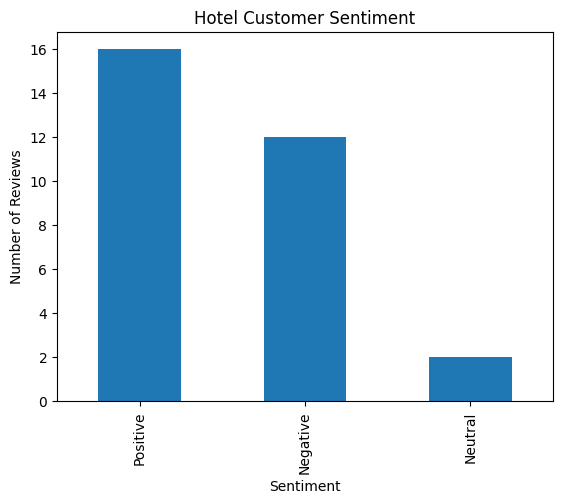

In [9]:
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Hotel Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [10]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned"])
y = df["Sentiment"]

model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [11]:
review = input("\nEnter a hotel review: ")

cleaned = clean(review)

prediction = model.predict(
    vectorizer.transform([cleaned])
)

print("Predicted Sentiment:", prediction[0])


Enter a hotel review: 5
Predicted Sentiment: Positive
